In [1]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from roc_utils import *

/usr/local/lib/python3.9/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
with open('results/metahate-results-no-finetune-0301.pkl', 'rb') as f:
    pred_e5_base, truth_e5_base, logits_e5_base, results_e5_base = pickle.load(f)
with open('results/metahate-results-0301.pkl', 'rb') as f:
    pred_e5_fine, truth_e5_fine, logits_e5_fine, results_e5_fine = pickle.load(f)

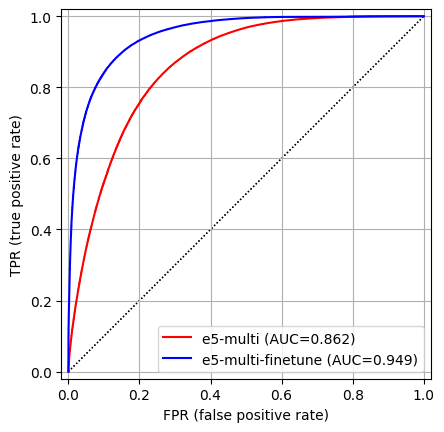

In [3]:
thrType = "minopt"
showOpt = False
sigmoid = lambda x: 1/(1 + np.exp(-x))   # Use sigmoid to estimate probabilities
fig, ax3 = plt.subplots()
probs_roc1 = sigmoid(logits_e5_base) 
roc1 = compute_roc(X=probs_roc1[:, 1], y=truth_e5_base, pos_label=1, objective=thrType)
plot_roc(roc1, label="e5-multi", color="red", ax=ax3, show_opt=showOpt)
probs_roc2 = sigmoid(logits_e5_fine) 
roc1 = compute_roc(X=probs_roc2[:, 1], y=truth_e5_fine, pos_label=1, objective=thrType)
plot_roc(roc1, label="e5-multi-finetune", color="blue", ax=ax3, show_opt=showOpt)

In [4]:
from transformer_classifier import calculate_scores

def calculate_summary(actual, predictions, model_name):
    summary = calculate_scores(actual, predictions)
    summary['model'] = model_name
    return summary

pd.DataFrame([
    calculate_summary(truth_e5_base, pred_e5_base, 'E5-multi'),
    calculate_summary(truth_e5_fine, pred_e5_fine, 'E5-multi-finetune'),
])

2025-03-04 15:26:22.374715: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-04 15:26:24.128696: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:/usr/local/cuda/extras/CUPTI/lib64
2025-03-04 15:26:24.128873: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:/usr/local/cuda/extras/CUPTI/lib64
2025-03-04 15:26

,accuracy,f1_score,precision,recall,kappa,roc_auc,model
0,0.824824,0.460216,0.641811,0.358719,0.365502,0.745367,E5-multi
1,0.904943,0.761239,0.797758,0.727917,0.702053,0.863918,E5-multi-finetune


Export data:

In [5]:
data_dir = "../data"
df = pd.read_csv(Path(data_dir)/"MetaHate.tsv", sep='\t')
index_removed = pd.read_csv(Path(data_dir)/".."/"dedup"/"removed.csv", header=None)[0].tolist()
df = df.loc[df.index.difference(index_removed)].reset_index(drop=True)
df.to_csv(Path(data_dir)/"MetaHate_cleaned.csv", index=None, sep='\t')